# Import and inputs

In [2]:
# Imports and setup
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

import pandas as pd

repo_root = "/home/volt/bach/SynFlow"
case_study_root = f"{repo_root}/notebooks"
for path in (repo_root, case_study_root):
    if path not in sys.path:
        sys.path.insert(0, path)

# Notebook-specific imports
from SynFlow.Explorer import replace_in_sfiller_df_column
from SynFlow.Explorer.sfiller_df import extract_1_slot_col
from SynFlow.SCD import (
    plot_dist_by_period,
    plot_items_dist_contrib_by_period,
    print_dist_contrib_by_period,
    sfillers_dist_contrib_by_period,
)
from SynFlow.SCD.freq import plot_freq_top_union_sfillers_by_period

# Analysis

In [3]:
# RSC
target_lemma = "viral"
target_pos = "ADJ"
period = "1995-2025"
corpus_folder = f"/home/volt/bach/Corpora/deu_news_1995-2025_sentences_parsed"

In [4]:
output_folder = Path(f"/home/volt/bach/SynFlow/notebooks/")
input_SCD = output_folder / "input" /f"{target_lemma}_{target_pos}_{period}" / "SCD"
os.makedirs(input_SCD, exist_ok=True)

### Viral

In [5]:
# all_sfillers_df_path = "/home/volt/bach/SynFlow/notebooks/input/viral_ADJ_1995-2025/SCD/viral_ADJ_slot_type_df.csv"
all_sfillers_df_path = "/home/volt/bach/SynFlow/notebooks/input/viral_ADJ_1995-2025/SCD/viral_ADJ_sfiller_df_token_only_all.csv"
# all_sfillers_df_path = "/home/volt/bach/SynFlow/notebooks/input/viral_ADJ_1995-2025/SCD/viral_ADJ_construction_df.csv"
# all_sfillers_df_path = "/home/volt/bach/SynFlow/notebooks/input/viral_ADJ_1995-2025/SCD/viral_ADJ_feat_type_df.csv"
# all_sfillers_df_path = "/home/volt/bach/SynFlow/notebooks/input/viral_ADJ_1995-2025/SCD/viral_ADJ_feat_df_all.csv"

In [63]:
interest_slot = "Variant"
single_slot_df_path = f"{input_SCD}/{target_lemma}_{target_pos}_{interest_slot}.csv"
# Extract the specific slot-filler column
single_slot_df = extract_1_slot_col(all_sfillers_df_path, interest_slot, output_path=single_slot_df_path, explode=False)

In [64]:
# Load dataframe
single_slot_df = pd.read_csv(single_slot_df_path)

# save if needed
single_slot_df.to_csv(single_slot_df_path, index=False)

#### Preprocessing

This step is unique to the type of data we're working with.

In [103]:
# # Replace the slot-fillers for specific slot
# replacements = {
#     # old_value: new_value
# }

# replace_in_sfiller_df_column(
#     single_slot_df_path,
#     interest_slot,
#     replacements=replacements,
#     output_path=single_slot_df_path,
# )


#### Frequency Changes

In [6]:
# Bar chart (absolute freq)
plot_freq_top_union_sfillers_by_period(single_slot_df_path, 
                              slot_type=interest_slot,
                              top_n=10,
                              normalized=True, # Normalized or Raw count
                              time_col="subfolder",
                              )

NameError: name 'single_slot_df_path' is not defined

#### Distance contribution

In [56]:
sfillers_dist_contrib_results = sfillers_dist_contrib_by_period(single_slot_df, 
                                             slot_col=interest_slot,
                                             min_freq=1, 
                                             period_col="subfolder",
                                             measure="tvd",
                                             weighting=True,
                                             top_n=10,
                                             k=100
                                             )
sfillers_dist_contrib_results
# print_dist_contrib_by_period(sfillers_dist_contrib_results)

{'1995-2000 vs 2001-2005': {'measure': 'tvd',
  'dist': 0.01,
  'top_shifted_items': [{'item': "bo_('werden',)", 'contribution': 0.005},
   {'item': "lo_('hämorrhagischen',)", 'contribution': 0.003333333333333333},
   {'item': "lo_('hämorrhagisches',)",
    'contribution': 0.0016666666666666666}]},
 '2001-2005 vs 2006-2010': {'measure': 'tvd',
  'dist': 0.01,
  'top_shifted_items': [{'item': "lo_('werden',)", 'contribution': 0.005},
   {'item': "bo_('verbreiten',)", 'contribution': 0.0016666666666666666},
   {'item': "bo_('verbreitet',)", 'contribution': 0.0016666666666666666},
   {'item': "bo_('attackierte',)", 'contribution': 0.0008333333333333333},
   {'item': "bo_('gestreut',)", 'contribution': 0.0008333333333333333}]},
 '2006-2010 vs 2011-2015': {'measure': 'tvd',
  'dist': 0.043199999999999995,
  'top_shifted_items': [{'item': "de_('verbreiten',)", 'contribution': 0.0088},
   {'item': "lo_('attackierte',)", 'contribution': 0.004999999999999999},
   {'item': "de_('verbreitet',)", 

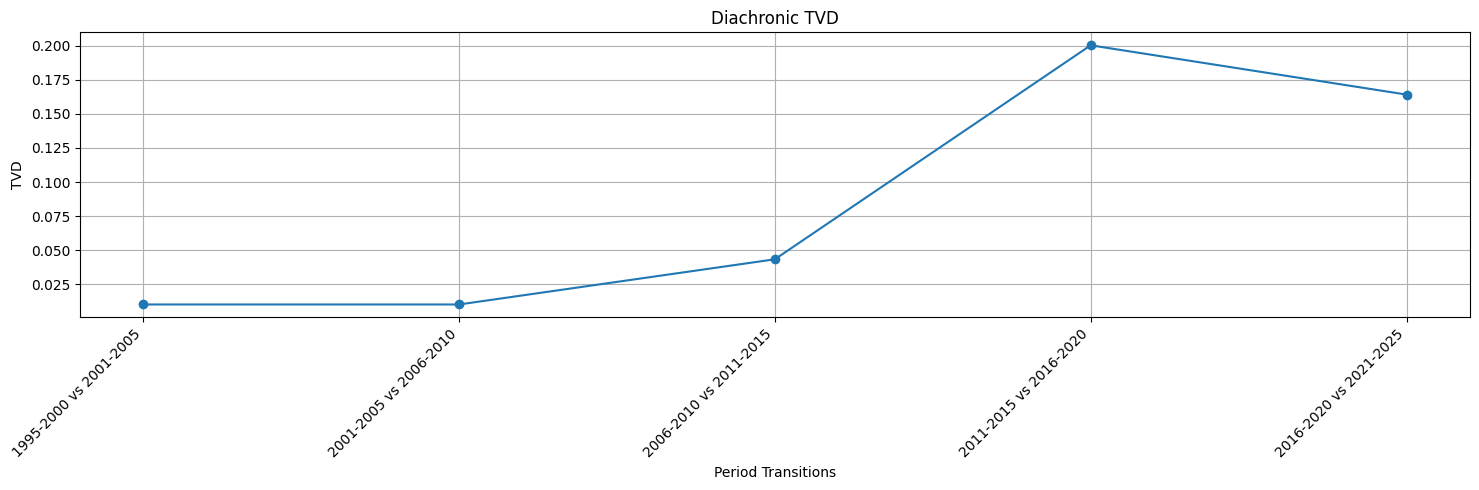

In [57]:
plot_dist_by_period(sfillers_dist_contrib_results)

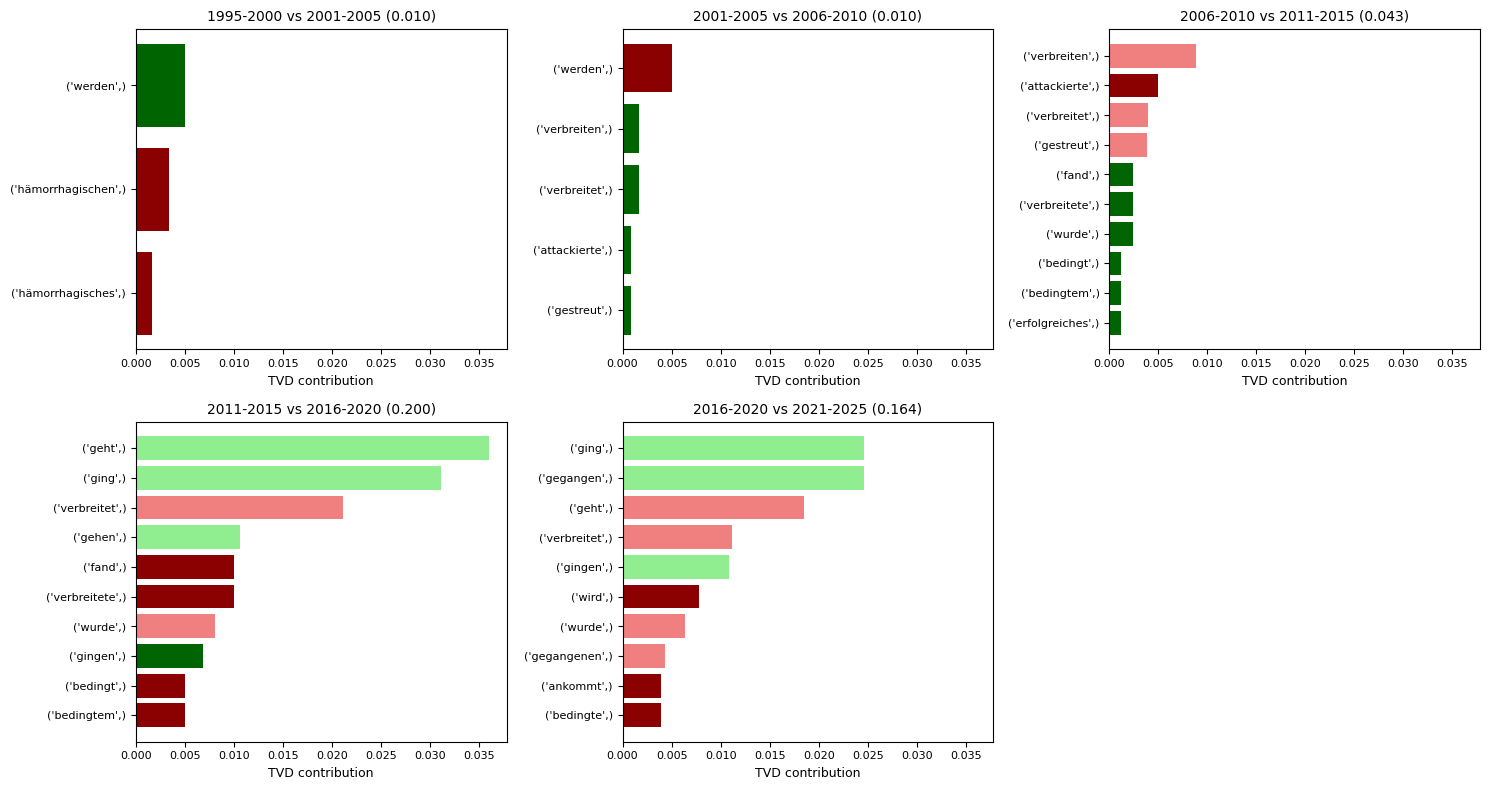

In [58]:
plot_items_dist_contrib_by_period(sfillers_dist_contrib_results, top_n=10, cols=3)